In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv ('C:\Data Science Study\MODUL 2\Transjakarta\Transjakarta.csv')
df.head(5)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-null  object 
 16  tapOutStopsName   36556 non-null  object

In [ ]:
df.describe()

,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
count,3.790000e+04,37900.000000,37900.000000,37900.000000,37900.000000,37900.000000,36556.000000,36556.000000,36556.000000,36893.000000
mean,4.250060e+17,1990.089314,0.500633,-6.214838,106.841554,13.572480,-6.214651,106.841233,21.219909,2699.712683
std,1.321699e+18,13.051482,0.500006,0.057911,0.060369,12.237623,0.059022,0.060999,13.800689,4212.225592
min,6.040368e+10,1946.000000,0.000000,-6.394973,106.614730,0.000000,-6.394973,106.614730,1.000000,0.000000
25%,1.800442e+14,1982.000000,0.000000,-6.245863,106.803470,4.000000,-6.247225,106.801750,11.000000,0.000000
50%,3.507947e+15,1990.000000,1.000000,-6.214587,106.834830,10.000000,-6.214718,106.834580,18.000000,3500.000000
75%,4.699023e+15,2001.000000,1.000000,-6.175528,106.882270,19.000000,-6.174736,106.883030,29.000000,3500.000000
max,4.997694e+18,2012.000000,1.000000,-6.089429,107.023950,68.000000,-6.091746,107.023660,77.000000,20000.000000


Dari analisis deskriptif, terlihat bahwa kuartil bawah (25%) bernilai 0, yang menunjukkan proporsi signifikan perjalanan gratis. Selain itu, mean yang lebih rendah dari median mengindikasikan distribusi yang skewed akibat banyaknya transaksi bernilai nol. Ini mengarah pada insight bahwa revenue tidak merepresentasikan volume penumpang secara akurat

Data Cleaning

In [7]:
# Convert datetime
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])

# Durasi perjalanan
df['duration_min'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60

# Jam masuk
df['hour'] = df['tapInTime'].dt.hour

df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,duration_min,hour
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0,39.150000,5
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0,57.283333,5
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0,51.816667,5
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0,43.416667,5
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0,39.466667,6


Saya melakukan feature engineering dengan mengubah kolom waktu menjadi format datetime, lalu menurunkan dua variabel penting yaitu durasi perjalanan dan jam masuk. Ini memungkinkan saya menganalisis pola perilaku penumpang serta distribusi penggunaan berdasarkan waktu

EDA

In [8]:
df['payAmount'].value_counts(normalize=True) * 100

payAmount
3500.0     50.153146
0.0        45.125091
20000.0     4.721763
Name: proportion, dtype: float64

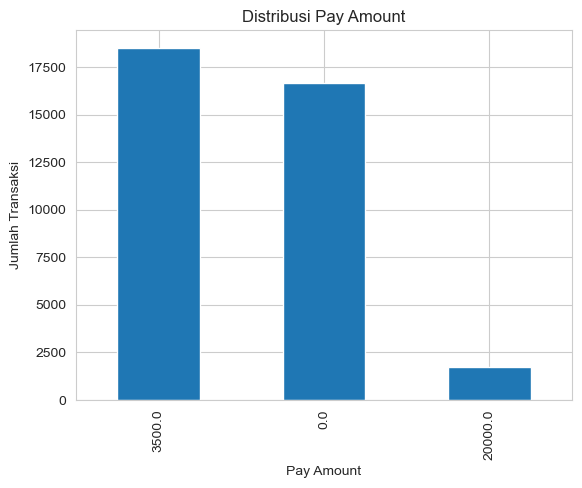

In [9]:
df['payAmount'].value_counts().plot(kind='bar')
plt.title("Distribusi Pay Amount")
plt.xlabel("Pay Amount")
plt.ylabel("Jumlah Transaksi")
plt.show()

Distribusi pembayaran menunjukkan bahwa sekitar 45% transaksi bernilai nol, yang mengindikasikan adanya skema tarif terintegrasi atau subsidi. Hal ini menyebabkan revenue tidak mencerminkan volume penumpang secara langsung, Distribusi ini membuktikan bahwa sistem TransJakarta bukan revenue-driven system, tapi service-driven system dengan banyak transaksi non-monetized.

In [10]:
zero_pct = (df['payAmount'] == 0).mean() * 100
print(f"Persentase transaksi Rp0: {zero_pct:.2f}%")

Persentase transaksi Rp0: 43.93%


Durasi perjalanan

In [11]:
df['duration_min'].describe()

count    36556.000000
mean        72.125424
std         28.072912
min         15.000000
25%         51.133333
50%         71.833333
75%         95.800000
max        179.050000
Name: duration_min, dtype: float64

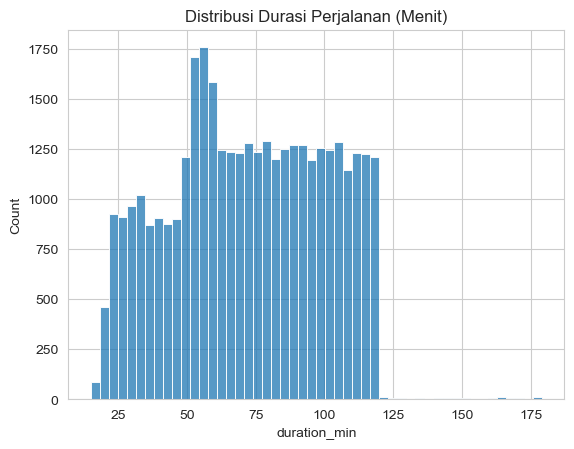

In [12]:
sns.histplot(df['duration_min'], bins=50)
plt.title("Distribusi Durasi Perjalanan (Menit)")
plt.show()

TransJakarta digunakan untuk perjalanan panjang (±72 menit), namun tidak semua perjalanan tersebut menghasilkan revenue, yang memperkuat bahwa sistem ini lebih berorientasi pada layanan dibanding monetisasi.

Peak Hour

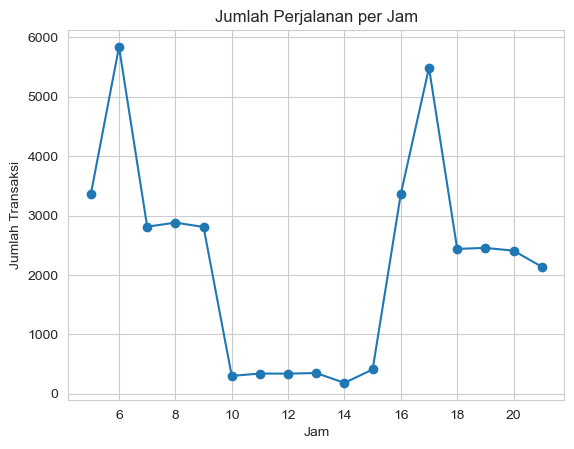

In [13]:
hourly = df.groupby('hour').size()

hourly.plot(kind='line', marker='o')
plt.title("Jumlah Perjalanan per Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Transaksi")
plt.show()

TransJakarta mengalami lonjakan penggunaan pada jam sibuk (06.00 dan 17.00) yang didominasi oleh commuter, namun menariknya hampir setengah dari transaksi tersebut tidak menghasilkan revenue

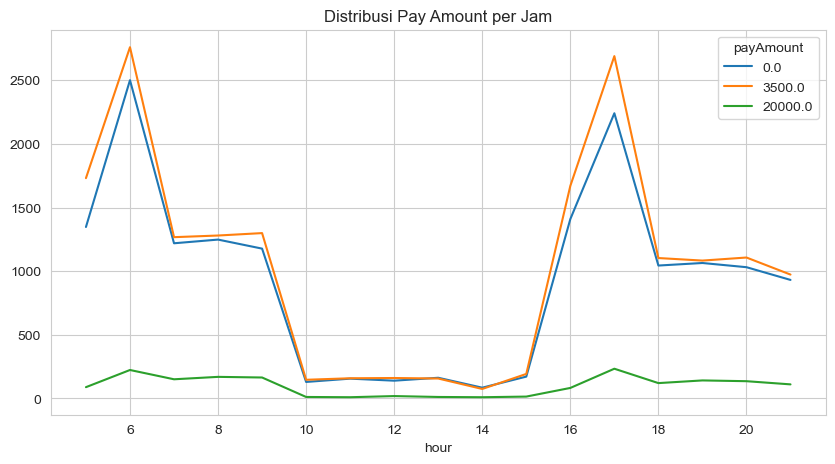

In [14]:
pivot = df.pivot_table(
    index='hour',
    columns='payAmount',
    values='duration_min',
    aggfunc='count'
)

pivot.plot(figsize=(10,5))
plt.title("Distribusi Pay Amount per Jam")
plt.show()

Lonjakan penggunaan TransJakarta pada jam sibuk didorong oleh penumpang berbayar dan tidak berbayar secara bersamaan, sehingga peningkatan demand tidak diikuti oleh peningkatan revenue yang sebanding.Permasalahan utama TransJakarta bukan pada kurangnya penumpang, tetapi pada bagaimana sistem tarif saat ini menyebabkan sebagian besar pertumbuhan demand tidak berkontribusi langsung terhadap revenue

In [15]:
print("AHA MOMENT")
print(f"""
Sebanyak {zero_pct:.2f}% perjalanan memiliki nilai pembayaran 0.
Artinya hampir setengah aktivitas tidak menghasilkan revenue langsung.

Implikasi:
- Revenue tidak mencerminkan jumlah penumpang
- Kemungkinan adanya sistem tarif integrasi / subsidi
""")

AHA MOMENT

Sebanyak 43.93% perjalanan memiliki nilai pembayaran 0.
Artinya hampir setengah aktivitas tidak menghasilkan revenue langsung.

Implikasi:
- Revenue tidak mencerminkan jumlah penumpang
- Kemungkinan adanya sistem tarif integrasi / subsidi



In [16]:
print("DATA STORY")
print("""
1. Volume penumpang tinggi, tetapi tidak semua menghasilkan revenue
2. Hampir setengah transaksi bernilai Rp0
3. Pola penggunaan sangat terkonsentrasi pada jam sibuk
4. Durasi perjalanan menunjukkan penggunaan untuk commuting jarak jauh

KESIMPULAN:
Masalah utama bukan jumlah penumpang, tetapi monetisasi dan distribusi demand.
""")

DATA STORY

1. Volume penumpang tinggi, tetapi tidak semua menghasilkan revenue
2. Hampir setengah transaksi bernilai Rp0
3. Pola penggunaan sangat terkonsentrasi pada jam sibuk
4. Durasi perjalanan menunjukkan penggunaan untuk commuting jarak jauh

KESIMPULAN:
Masalah utama bukan jumlah penumpang, tetapi monetisasi dan distribusi demand.



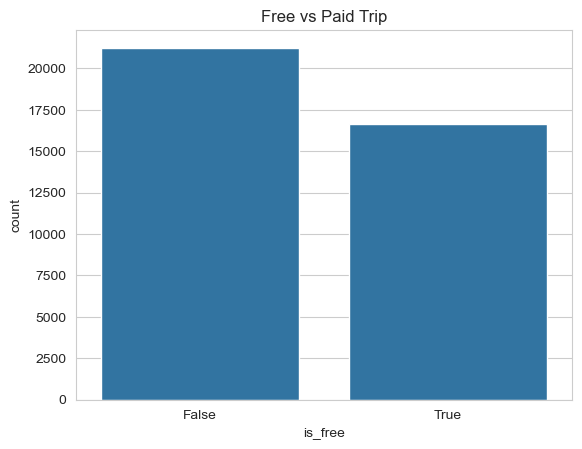

In [17]:
df['is_free'] = df['payAmount'] == 0

sns.countplot(x='is_free', data=df)
plt.title("Free vs Paid Trip")
plt.show()